In [1]:
from scripts.graph_connector import query_executor
from scripts.community_scoring import *
from scripts.neo4j_to_networkx import graph_from_cypher
from scripts.louvain_community_detection import *
from scripts.sample_queries import *
import pandas as pd
import networkx as nx
import plotly.graph_objects as go
import json
from pandas import json_normalize
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# query neo4j and read into in-memory graph
data = query_executor(query_all_data)
G = graph_from_cypher(data)


Node or Edge import error - Type error - continuing
Node or Edge import error - Attribute error - continuing
Node or Edge import error - Type error - continuing
Node or Edge import error - Attribute error - continuing
total nodes: 22320, total edges: 29590


In [3]:
# run louvain algo
communities = louvain_community(G)

Generating communities...
Community detection elapsed time: 1.193784236907959
total communities with more than one node: 64


In [4]:
subcommunities = select_communities(communities, 5)
len(subcommunities)

5

In [5]:
for community in subcommunities:
    community_score(G, community, type='log',verbose =True)

density: 0.0008180749318315245 fraud_density: 0.0008078821254962925 score: 0.0011687920309926508
density: 0.0010826293007009816 fraud_density: 0.000999743940861472 score: 0.0015165956860285215
density: 0.0010117083596595917 fraud_density: 0.0011659072432553097 score: 0.0015177604941831718
density: 0.0019138755980861245 fraud_density: 0.0017815435325520964 score: 0.0026869017379608194
density: 0.0022261661237862407 fraud_density: 0.0018505640550146808 score: 0.0030291131577630847


In [6]:
df_communities_stats = get_communities_stats(G,communities)
df_sorted = df_communities_stats.sort_values(by='Score', ascending=False)

In [7]:
df_sorted.to_csv('data/communities_stats.csv')

In [8]:
top_subcommunities = df_communities_stats[df_communities_stats['N_Nodes']>1000]

In [9]:
top_subcommunities.Community_id.values

array([ 2,  3, 10, 52], dtype=int64)

In [10]:
nodes_df =pd.DataFrame()
edges_df = pd.DataFrame()
for idx,community in enumerate(communities):
    if idx in top_subcommunities.Community_id.values:
      print(idx)
      community_subgraph = make_unfrozen_subgraph(G,community)
      df_n_fraud, df_e_fraud = graph_to_pandas(community_subgraph,False)
      df_n_fraud['Community_id'] = idx
      df_e_fraud['Community_id'] = idx
      nodes_df = pd.concat([nodes_df,df_n_fraud])
      edges_df = pd.concat([edges_df,df_e_fraud])

2
3
10
52


In [11]:
print(nodes_df['properties'])

16385    {'manifest': True, 'ServiceTypeCode': 144, 'pr...
16386    {'manifest': True, 'ServiceTypeCode': 144, 'pr...
16390    {'manifest': True, 'ServiceTypeCode': 144, 'pr...
6        {'MID_LAST_UPD_DATE': '2022-11-02', 'mailerid'...
16394    {'manifest': True, 'ServiceTypeCode': 144, 'pr...
                               ...                        
8105     {'destaddress_STATECODE': 'NJ', 'destaddress_S...
16345    {'constructcode': 'C03', 'scanned': True, 'man...
16355    {'constructcode': 'C03', 'scanned': True, 'man...
16356    {'constructcode': 'C03', 'scanned': True, 'man...
16358    {'constructcode': 'C03', 'scanned': True, 'man...
Name: properties, Length: 9502, dtype: object


In [12]:
# Normalize the properties column
properties_df = json_normalize(nodes_df['properties'])

# Concatenate the original DataFrame with the new properties DataFrame
nodes_df = pd.concat([nodes_df.drop(columns=['properties']), properties_df], axis=1)

         labels  Community_id manifest  ServiceTypeCode  \
16385   (label)           2.0      NaN              NaN   
16386   (label)           2.0      NaN              NaN   
16390   (label)           2.0      NaN              NaN   
6      (mailer)           2.0      NaN              NaN   
16394   (label)           2.0      NaN              NaN   
...         ...           ...      ...              ...   
9496        NaN           NaN      NaN              NaN   
9498        NaN           NaN     True              1.0   
9499        NaN           NaN     True              1.0   
9500        NaN           NaN     True              1.0   
9501        NaN           NaN     True             55.0   

      prtnrscan_createdtimestamp   spef  \
16385                        NaN    NaN   
16386                        NaN    NaN   
16390                        NaN    NaN   
6                            NaN    NaN   
16394                        NaN    NaN   
...                          ... 

In [13]:
nodes_df['labels'] = nodes_df['labels'].apply(str).str.extract(r'\'(\w+)\'')

In [15]:
#nodes_df.to_csv('nodes_data.csv', index=False)

In [16]:
print(nodes_df.columns)
print(nodes_df.head())

Index(['labels', 'Community_id', 'manifest', 'ServiceTypeCode',
       'prtnrscan_createdtimestamp', 'spef', 'parcelidcode', 'constructcode',
       'scanned', 'createdtimestamp', 'detailsequence', 'mailclasscode',
       'applicationid', 'manifestid', 'prtnrscan_eventcode',
       'manifest_createdtimestamp', 'MID_LAST_UPD_DATE', 'mailerid',
       'MID_LAST_UPD_USERID', 'destaddress_STATECODE', 'destaddress_STATENAME',
       'destaddress_zipcode', 'destaddress_CITY', 'CRID_msp_flag', 'CRID',
       'CRID_cmra_flag', 'UBK', 'USPSDimensionalHeight',
       'USPSDimensionalWidth', 'customerrecordstartdate', 'mailpieceid',
       'USPSDimensionalLength', 'sourceid', 'firstscan_STATECODE',
       'firstscan_zipcode', 'firstscan_CITY', 'firstscan_STATENAME',
       'firstscan_COUNTYNM'],
      dtype='object')
       labels  Community_id manifest  ServiceTypeCode  \
16385   label           2.0      NaN              NaN   
16386   label           2.0      NaN              NaN   
16390   lab

In [17]:
df_communities_stats

,Community_id,Density,Fraud_Density,Score,N_Nodes,N_Edges
0,0,0.400000,0.200000,0.479181,5,4
1,1,0.010054,0.008434,0.013702,219,240
2,2,0.001012,0.001166,0.001518,2265,2594
3,3,0.001083,0.001000,0.001517,2548,3513
4,4,0.002809,0.003420,0.004292,714,715
...,...,...,...,...,...,...
59,59,0.002800,0.002164,0.003738,852,1015
60,60,0.166667,0.194444,0.243833,12,11
61,61,0.004153,0.003452,0.005650,499,516
62,62,0.021743,0.017642,0.029339,102,112


In [18]:
# merge nodes_df with df_communities_stats on Community_id
nodes_df = nodes_df.merge(df_communities_stats[['Community_id', 'Density', 'Fraud_Density', 'Score']], on='Community_id', how='left')

In [19]:
nodes_df

,labels,Community_id,manifest,ServiceTypeCode,prtnrscan_createdtimestamp,spef,parcelidcode,constructcode,scanned,createdtimestamp,...,sourceid,firstscan_STATECODE,firstscan_zipcode,firstscan_CITY,firstscan_STATENAME,firstscan_COUNTYNM,Density,Fraud_Density,Score,Fraud_Status
0,label,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.001012,0.001166,0.001518,Not Fraud
1,label,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.001012,0.001166,0.001518,Not Fraud
2,label,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.001012,0.001166,0.001518,Not Fraud
3,mailer,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.001012,0.001166,0.001518,Not Fraud
4,label,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.001012,0.001166,0.001518,Not Fraud
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Fraud
14701,NaN,NaN,True,1.0,NaN,False,e90814ee87ce55902e916da0042c669e5c2d7fa4f61585...,C03,True,2024-05-01T17:36:39.000Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Fraud
14702,NaN,NaN,True,1.0,NaN,False,025edbb0040e06451c4753010b26b5f673e79526345177...,C03,True,2024-05-01T16:39:32.000Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Fraud
14703,NaN,NaN,True,1.0,NaN,False,a8a442d3ade5118f84ae8f065bd054a2a69eb7b660214c...,C03,True,2024-05-01T16:39:32.000Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Fraud


In [24]:
def determine_fraud_status(row):
    if row['Score'] > 0.002:  # Adjust criteria
        return 'Fraud'
    else:
        return 'Not Fraud'

In [25]:
nodes_df['Fraud_Status'] = nodes_df.apply(determine_fraud_status, axis=1)

In [26]:
nodes_df['Fraud_Status'].value_counts()

Fraud_Status
Not Fraud    13374
Fraud         1331
Name: count, dtype: int64

In [29]:
# Ensure 'labels' column contains strings
nodes_df['labels'] = nodes_df['labels'].astype(str)

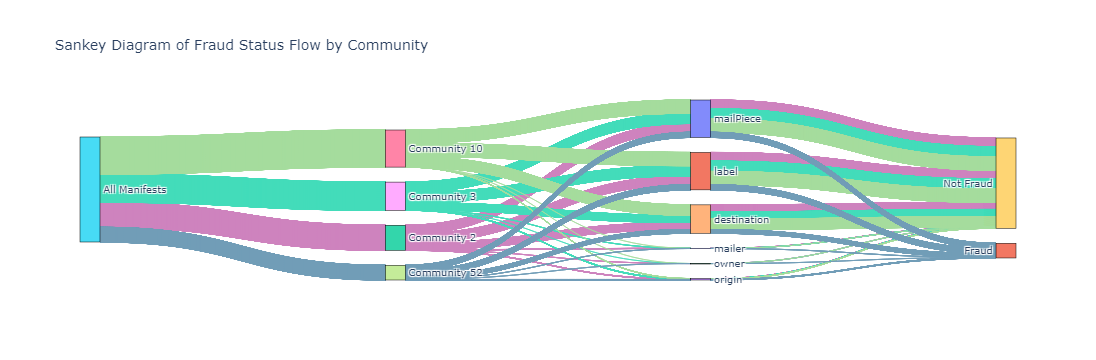

In [34]:
import random

# Ensure 'manifestid' is part of your DataFrame
nodes_df['manifestid'] = nodes_df['manifestid'].fillna('Unknown')
nodes_df['Community_id'] = nodes_df['Community_id'].fillna(-1)

# Generate a unique color for each community
def generate_community_colors(df):
    communities = df['Community_id'].unique()
    community_colors = {}
    for community in communities:
        if community != -1:  # Exclude unknown community
            community_colors[community] = f'rgba({random.randint(0, 255)}, {random.randint(0, 255)}, {random.randint(0, 255)}, 0.8)'
    return community_colors

community_colors = generate_community_colors(nodes_df)

# Prepare data for Sankey diagram
def prepare_sankey_data(df):
    source = []
    target = []
    value = []
    colors = []

    manifest_label = 'All Manifests'

    for _, row in df.iterrows():
        if row['Community_id'] == -1:
            continue  # Exclude unknown community

        community_id = f"Community {int(row['Community_id'])}"
        label = row['labels']
        fraud_status = row['Fraud_Status']

        source.extend([manifest_label, community_id, label])
        target.extend([community_id, label, fraud_status])
        value.extend([1, 1, 1])

        # Use the same color for all links associated with the same community
        community_color = community_colors[int(row['Community_id'])]
        colors.extend([community_color, community_color, community_color])

    return source, target, value, colors

source, target, value, colors = prepare_sankey_data(nodes_df)

# Create labels list
labels = list(set(source + target))

# Map labels to indices
label_to_index = {label: i for i, label in enumerate(labels)}
source_indices = [label_to_index[src] for src in source]
target_indices = [label_to_index[tgt] for tgt in target]

# Create Sankey diagram
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels
    ),
    link=dict(
        source=source_indices,
        target=target_indices,
        value=value,
        color=colors
    )
))

fig.update_layout(title_text="Sankey Diagram of Fraud Status Flow by Community", font_size=10)
fig.show()